In [7]:
#importing libraries
import pandas as pd
df=pd.read_csv('Titanic-Dataset.csv')


In [8]:
#Data overview
print("First 5 rows:")
print(df.head()) 

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [9]:
#Dataset info
print("dataset info:")
print(df.info())

dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [10]:
#Dataset description
print ("decribe:")
print(df.describe())

decribe:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [11]:
#Data quality checks
missing = df.isnull().sum()
duplicates = df.duplicated().sum()
dtypres = df.dtypes
print("Missing values:\n", missing)
print("Duplicate rows:", duplicates)    
print("Data types:\n", dtypres)

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Duplicate rows: 0
Data types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [12]:
#Data cleaning
df["Age"] = df["Age"].fillna(df["Age"].mean())

df = df.drop_duplicates()

Embarked_mode = df["Embarked"].mode()[0]

df["Embarked"] = df["Embarked"].fillna(Embarked_mode)

df = df.drop(columns=["Cabin"])


In [13]:
#Data quality checks after cleaning
missing_after = df.isnull().sum()
duplicates_after = df.duplicated().sum()

after_summary = pd.DataFrame({
    "Missing Values": missing_after,
    "Data Type": df.dtypes
})

after_summary["Duplicates"] = duplicates_after

print("After Cleaning:\n", after_summary)

After Cleaning:
              Missing Values Data Type  Duplicates
PassengerId               0     int64           0
Survived                  0     int64           0
Pclass                    0     int64           0
Name                      0    object           0
Sex                       0    object           0
Age                       0   float64           0
SibSp                     0     int64           0
Parch                     0     int64           0
Ticket                    0    object           0
Fare                      0   float64           0
Embarked                  0    object           0


In [14]:
#Data visualization
import matplotlib.pyplot as plt

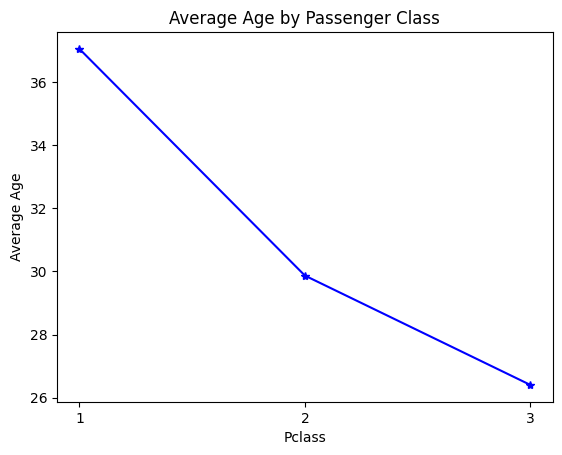

In [15]:
#line chart 
df.groupby("Pclass")["Age"].mean().plot(kind="line", marker="*" , color="Blue",title="Average Age by Passenger Class")
plt.ylabel("Average Age")
plt.xticks([1, 2, 3], ['1', '2', '3'])
plt.show()

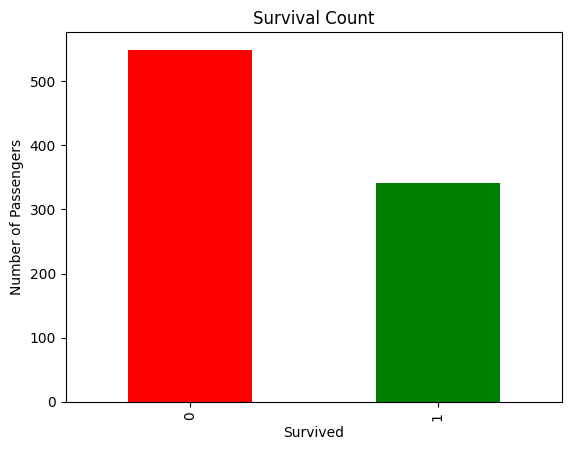

In [16]:
#Bar Chart    
df["Survived"].value_counts().plot(kind="bar", color=["red", "green"], title="Survival Count")
plt.ylabel("Number of Passengers")
plt.show()

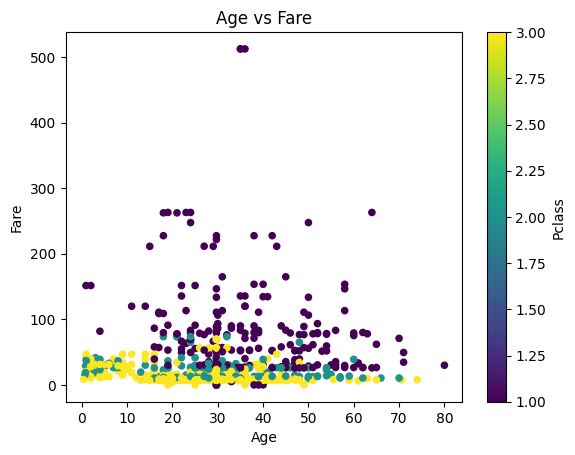

In [17]:
#Scatter Plot
df.plot.scatter(x="Age", y="Fare", c="Pclass", colormap="viridis", title="Age vs Fare" , )
plt.show()

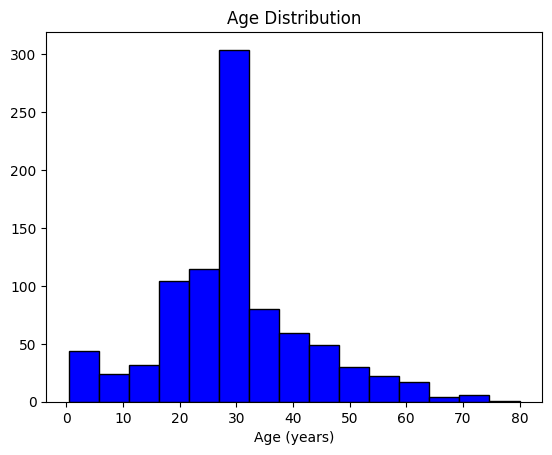

In [18]:
#Histogram
df["Age"].plot.hist(bins=15, color='blue', edgecolor='black', title="Age Distribution")
plt.xlabel("Age (years)")
plt.ylabel("")
plt.show()

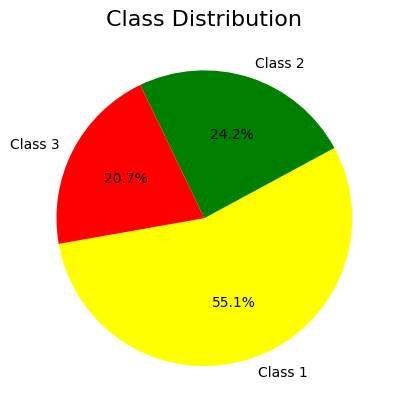

In [19]:
#Pie Chart
colors = ['yellow','green','red']
  
df["Pclass"].value_counts().plot.pie(
    labels=["Class 1","Class 2","Class 3"],
    autopct="%1.1f%%",
    startangle=190,
    colors=colors,
    title="Class Distribution"
)

plt.ylabel("")  
plt.title("Class Distribution", fontsize=16)  # bigger title
plt.show()

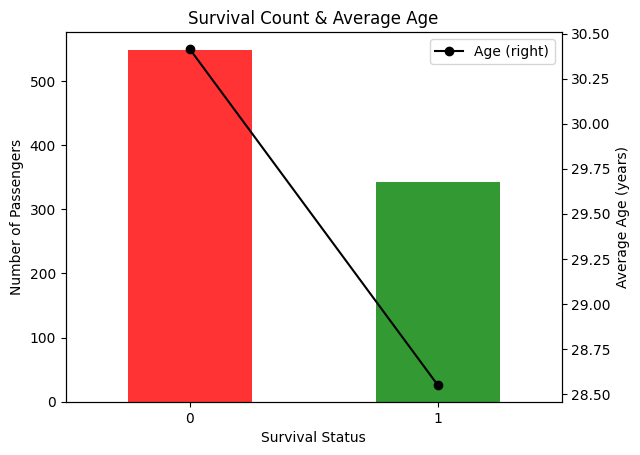

In [20]:
#Combined Bar and Line Chart
fig, ax = plt.subplots()

df["Survived"].value_counts().plot.bar(
    ax=ax, color=['red','green'], alpha=0.8
)


df.groupby("Survived")["Age"].mean().plot.line(
    ax=ax, color='black', marker='o', secondary_y=True, legend=True
)


ax.set_xlabel("Survival Status")
ax.set_ylabel("Number of Passengers")
ax.right_ax.set_ylabel("Average Age (years)")
ax.set_title("Survival Count & Average Age")

plt.show()
plt.show()

In [21]:
#Pair Plot
import seaborn as sns


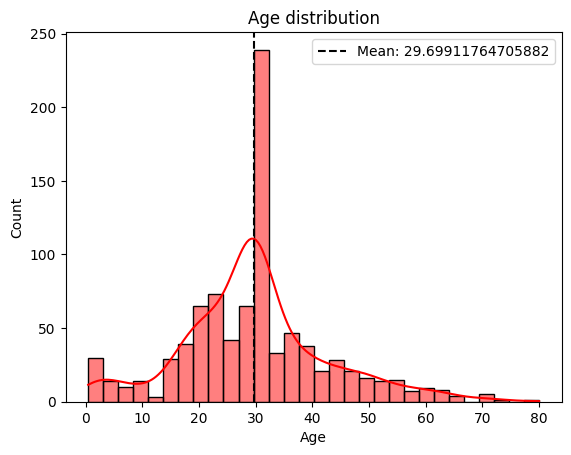

In [22]:
# Adjusting the title position to avoid overlap
sns.histplot(df['Age'].dropna(), kde=True, color='Red')
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.axvline(df['Age'].mean(), color='black', linestyle='--', label=f"Mean: {df['Age'].mean()}")
plt.legend()
plt.show()

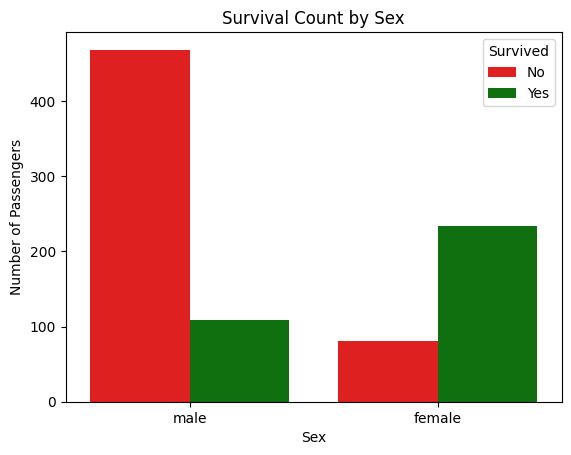

In [23]:
#Count Plot
sns.countplot(x='Sex', hue='Survived', data=df ,palette=['red','green'])
plt.title("Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=['No','Yes'])
plt.show()

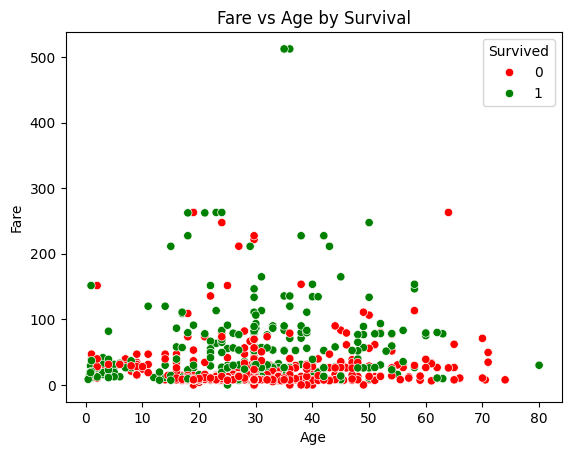

In [24]:
#Scatter Plot
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df, palette=['red','green'])
plt.title("Fare vs Age by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

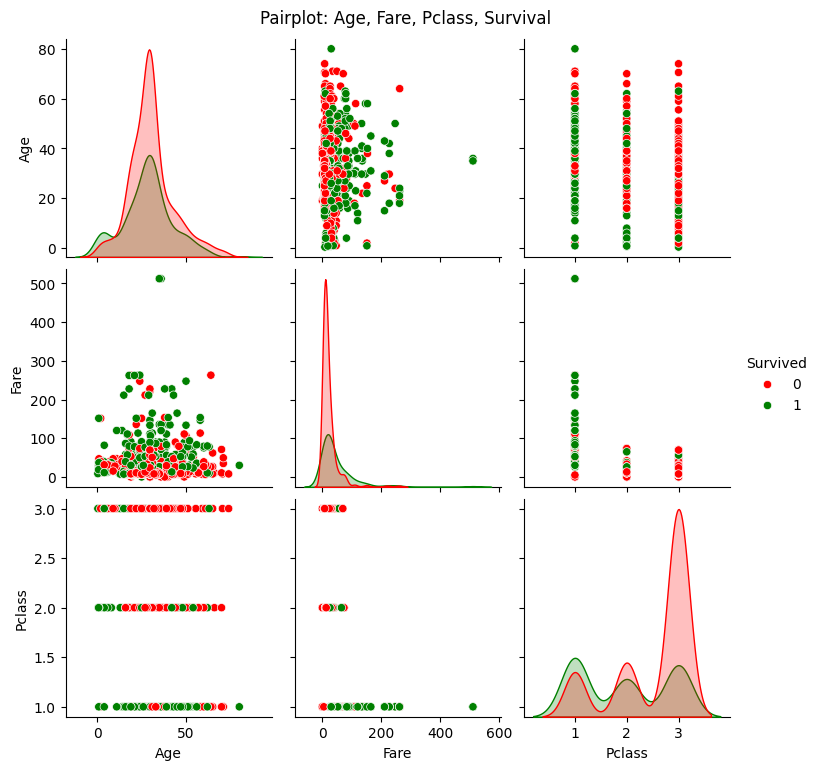

In [25]:
#Box Plot
sns.pairplot(df[['Age','Fare','Pclass','Survived']].dropna(), hue='Survived', palette=['red','green'])
plt.suptitle("Pairplot: Age, Fare, Pclass, Survival", y=1.02)
plt.show()

In [ ]:
import plotly.express as px

avg_age = df.groupby("Pclass")["Age"].mean().reset_index() # Calculate average age by passenger class

fig = px.line(
    avg_age,
    x="Pclass",
    y="Age",
    markers=True,
    title="Average Age by Passenger Class"
)
# Customize axes labels
fig.update_layout(
    xaxis_title="Passenger Class",
    yaxis_title="Average Age"
)

fig.show()

In [28]:
survival_count = df["Survived"].value_counts().reset_index()
survival_count.columns = ["Survived", "Count"]

fig = px.bar(
    survival_count,
    x="Survived",
    y="Count",
    color="Survived",
    title="Survival Count"
)

fig.show()

In [29]:
fig = px.scatter(
    df,
    x="Age",
    y="Fare",
    color="Survived",
    size="Fare",
    hover_data=["Sex", "Pclass"],
    title="Age vs Fare"
)

fig.show()

In [30]:
fig = px.scatter(
    df,
    x="Age",
    y="Fare",
    animation_frame="Pclass",
    color="Survived",
    size="Fare",
    title="Animated Titanic Scatter Plot"
)

fig.show()

In [ ]:
import pandas as pd
from dash import Dash, dcc, html, Input, Output
import plotly.express as px

# Load dataset

df = pd.read_csv("Titanic-Dataset.csv")

# Clean data

df["Age"] = df["Age"].fillna(df["Age"].mean())

# Create app

app = Dash(__name__)
# Define app layout html structure
app.layout = html.Div([

    html.H1("Titanic Interactive Dashboard"),

    dcc.Dropdown(
        id='class-dropdown',
        options=[
            {'label': 'Class 1', 'value': 1},
            {'label': 'Class 2', 'value': 2},
            {'label': 'Class 3', 'value': 3}
        ],
        value=1,
        clearable=False
    ),

    dcc.Graph(id='scatter-chart'),
    dcc.Graph(id='bar-chart')
])
# Define callback to update charts based on dropdown selection
@app.callback(
    Output('scatter-chart', 'figure'),
    Output('bar-chart', 'figure'),
    Input('class-dropdown', 'value')
)

def update_graphs(selected_class):

    filtered_df = df[df['Pclass'] == selected_class]

    scatter_fig = px.scatter(
        filtered_df,
        x='Age',
        y='Fare',
        color='Survived',
        hover_data=['Sex'],
        title='Age vs Fare'
    )

    bar_fig = px.histogram(
        filtered_df,
        x='Sex',
        color='Survived',
        barmode='group',
        title='Survival by Gender'
    )

    return scatter_fig, bar_fig

if __name__ == '__main__':
    app.run(debug=True)